# 1. Projeto de Análise de Dados
```
Projeto de Análise de Dados - 3° ADS - T1 / Disciplina: Sistemas de Informação

Alunos: Gabriela Viana Cunha - RA: 2411550012 / Kaique Alexandre Souza Kubota - RA: 2411550841 / Maria Vitória
Alvim Nardotto - RA: 2411550024

Dataset escolhido: Mental Health in Workplace - Kaggle

Ambiente de Desenvolvimento: Google Colab
```

# 2. Bibliotecas

In [1]:
# Imports das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import (
    MiniMap,
    Fullscreen,
    LocateControl,
    Geocoder,
    MousePosition,
    MeasureControl
)
import plotly.express as px

# 3. Dataset

In [2]:
# Carregando o dataset
df = pd.read_csv("mental_health_workplace.csv")

df.head()

,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,MHW0000001,2024,South Korea,Government & Public Sector,Manager/Team Lead,Contract,On-site,Large (1001-5000),18-24,Male,...,Yes,Yes,No,NaN,9.9,9.6,Likely,Prefer On-site,7,7.1
1,MHW0000002,2023,Australia,Education,Software Engineer,Full-time,On-site,Medium (201-1000),45-54,Male,...,Partial,Yes,No,Severe,4.1,5.2,Unlikely,No Preference,4,6.4
2,MHW0000003,2023,Canada,Technology,Marketing Specialist,Full-time,Hybrid,Small (51-200),45-54,Male,...,Yes,Yes,Yes,NaN,9.0,5.9,Very Unlikely,Prefer On-site,3,7.3
3,MHW0000004,2020,Brazil,Hospitality,Nurse,Full-time,Hybrid,Small (51-200),35-44,Male,...,Yes,No,NaN,Severe,3.6,9.2,Neutral,Prefer Remote,2,6.1
4,MHW0000005,2020,USA,Finance & Banking,Manager/Team Lead,Full-time,On-site,Enterprise (5000+),25-34,Non-binary,...,Partial,Yes,No,NaN,3.8,7.8,Unlikely,No Preference,2,7.5


# 4. Análises básicas iniciais

In [3]:
# Quantidade de linhas x colunas
df.shape

(10000, 34)

In [4]:
# Nome das colunas
df.columns

Index(['record_id', 'year', 'country', 'industry', 'job_role',
       'employment_type', 'work_model', 'company_size', 'age_group', 'gender',
       'years_of_experience', 'annual_salary_usd', 'weekly_work_hours',
       'weekly_overtime_hours', 'mental_health_condition', 'has_diagnosis',
       'treatment_type', 'stress_level', 'burnout_risk_score',
       'work_life_balance_score', 'productivity_score',
       'job_satisfaction_score', 'absenteeism_days_per_year',
       'employer_support_level', 'mental_health_policy_exists',
       'eap_available', 'used_eap', 'workplace_stigma_felt',
       'manager_support_score', 'team_collaboration_score',
       'intention_to_leave', 'remote_work_preference',
       'exercise_days_per_week', 'sleep_hours_per_night'],
      dtype='object')

In [5]:
# Tipos das colunas
df.dtypes

,0
record_id,object
year,int64
country,object
industry,object
job_role,object
employment_type,object
work_model,object
company_size,object
age_group,object
gender,object


In [6]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   record_id                    10000 non-null  object 
 1   year                         10000 non-null  int64  
 2   country                      10000 non-null  object 
 3   industry                     10000 non-null  object 
 4   job_role                     10000 non-null  object 
 5   employment_type              10000 non-null  object 
 6   work_model                   10000 non-null  object 
 7   company_size                 10000 non-null  object 
 8   age_group                    10000 non-null  object 
 9   gender                       10000 non-null  object 
 10  years_of_experience          10000 non-null  int64  
 11  annual_salary_usd            10000 non-null  int64  
 12  weekly_work_hours            10000 non-null  int64  
 13  weekly_overtime_h

In [7]:
# Primeiras linhas
df.head()

,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,MHW0000001,2024,South Korea,Government & Public Sector,Manager/Team Lead,Contract,On-site,Large (1001-5000),18-24,Male,...,Yes,Yes,No,NaN,9.9,9.6,Likely,Prefer On-site,7,7.1
1,MHW0000002,2023,Australia,Education,Software Engineer,Full-time,On-site,Medium (201-1000),45-54,Male,...,Partial,Yes,No,Severe,4.1,5.2,Unlikely,No Preference,4,6.4
2,MHW0000003,2023,Canada,Technology,Marketing Specialist,Full-time,Hybrid,Small (51-200),45-54,Male,...,Yes,Yes,Yes,NaN,9.0,5.9,Very Unlikely,Prefer On-site,3,7.3
3,MHW0000004,2020,Brazil,Hospitality,Nurse,Full-time,Hybrid,Small (51-200),35-44,Male,...,Yes,No,NaN,Severe,3.6,9.2,Neutral,Prefer Remote,2,6.1
4,MHW0000005,2020,USA,Finance & Banking,Manager/Team Lead,Full-time,On-site,Enterprise (5000+),25-34,Non-binary,...,Partial,Yes,No,NaN,3.8,7.8,Unlikely,No Preference,2,7.5


In [8]:
# Últimas linhas
df.tail()

,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
9995,MHW0009996,2024,UAE,Healthcare,Operations Manager,Full-time,On-site,Enterprise (5000+),25-34,Female,...,Partial,No,NaN,Moderate,5.8,5.3,Unlikely,Prefer Remote,5,7.5
9996,MHW0009997,2023,New Zealand,Consulting,Manager/Team Lead,Contract,Remote,Large (1001-5000),25-34,Male,...,No,No,NaN,NaN,8.3,8.1,Unlikely,No Preference,4,7.8
9997,MHW0009998,2020,Pakistan,Technology,Manager/Team Lead,Full-time,Remote,Medium (201-1000),25-34,Male,...,Yes,Yes,No,Mild,5.4,6.0,Very Likely,Strongly Prefer Remote,2,9.1
9998,MHW0009999,2020,Netherlands,Retail & E-commerce,Consultant,Full-time,On-site,Large (1001-5000),25-34,Female,...,No,Yes,No,NaN,8.3,7.7,Likely,Prefer On-site,2,7.4
9999,MHW0010000,2021,France,Education,Consultant,Full-time,On-site,Startup (1-50),18-24,Male,...,Yes,Yes,Yes,NaN,4.6,7.0,Likely,No Preference,2,9.1


# 5. Observações Inicias



```
O dataset possui informações relacionadas à saúde mental no ambiente corporativo, contendo dados sobre idade,
gênero, tratamento psicológico, ambiente de trabalho e histórico familiar

```

# 6. Renomeando colunas para Pt-BR


In [9]:
df = df.rename(columns={
    'record_id': 'ID_Registro',
    'year': 'Ano',
    'country': 'Pais',
    'industry': 'Industria',
    'job_role': 'Cargo',
    'employment_type': 'Tipo_Emprego',
    'work_model': 'Modelo_Trabalho',
    'company_size': 'Tamanho_Empresa',
    'age_group': 'Faixa_Etaria',
    'gender': 'Genero',
    'years_of_experience': 'Anos_Experiencia',
    'annual_salary_usd': 'Salario_Anual_USD',
    'weekly_work_hours': 'Horas_Semanais',
    'weekly_overtime_hours': 'Horas_Extras',
    'mental_health_condition': 'Condicao_Saude_Mental',
    'has_diagnosis': 'Possui_Diagnostico',
    'treatment_type': 'Tipo_Tratamento',
    'stress_level': 'Nivel_Estresse',
    'burnout_risk_score': 'Risco_Burnout',
    'work_life_balance_score': 'Equilibrio_Vida_Trabalho',
    'productivity_score': 'Produtividade',
    'job_satisfaction_score': 'Satisfacao_Trabalho',
    'absenteeism_days_per_year': 'Dias_Ausencia_Ano',
    'employer_support_level': 'Suporte_Empresa',
    'mental_health_policy_exists': 'Politica_Saude_Mental',
    'eap_available': 'EAP_Disponivel',
    'used_eap': 'Usou_EAP',
    'workplace_stigma_felt': 'Estigma_Trabalho',
    'manager_support_score': 'Suporte_Gestor',
    'team_collaboration_score': 'Colaboracao_Equipe',
    'intention_to_leave': 'Intencao_Sair',
    'remote_work_preference': 'Preferencia_Remoto',
    'exercise_days_per_week': 'Dias_Exercicio_Semana',
    'sleep_hours_per_night': 'Horas_Sono_Noite'
})

df.columns

Index(['ID_Registro', 'Ano', 'Pais', 'Industria', 'Cargo', 'Tipo_Emprego',
       'Modelo_Trabalho', 'Tamanho_Empresa', 'Faixa_Etaria', 'Genero',
       'Anos_Experiencia', 'Salario_Anual_USD', 'Horas_Semanais',
       'Horas_Extras', 'Condicao_Saude_Mental', 'Possui_Diagnostico',
       'Tipo_Tratamento', 'Nivel_Estresse', 'Risco_Burnout',
       'Equilibrio_Vida_Trabalho', 'Produtividade', 'Satisfacao_Trabalho',
       'Dias_Ausencia_Ano', 'Suporte_Empresa', 'Politica_Saude_Mental',
       'EAP_Disponivel', 'Usou_EAP', 'Estigma_Trabalho', 'Suporte_Gestor',
       'Colaboracao_Equipe', 'Intencao_Sair', 'Preferencia_Remoto',
       'Dias_Exercicio_Semana', 'Horas_Sono_Noite'],
      dtype='object')

# 7. Índice e Valores Nulos

In [10]:
# Organizando por índices
df = df.reset_index(drop=True)

In [11]:
# Análise de valores nulos
df.isna().sum() \
  .to_frame() \
  .reset_index() \
  .rename(columns={
      'index': 'Coluna',
      0: 'Total_Nulos'
  }) \
  .query('Total_Nulos > 0') \
  .sort_values(
      by=['Total_Nulos', 'Coluna'],
      ascending=[False, True],
      ignore_index=True
  )

,Coluna,Total_Nulos
0,Usou_EAP,4812
1,Condicao_Saude_Mental,3350
2,Estigma_Trabalho,2832
3,Suporte_Empresa,1018


# 8. Padronização dos valores categóricos
```
Nesta etapa foi realizada a tradução e padronização de alguns valores categóricos
do dataset, visando melhorar a legibilidade das análises e tabelas
```

In [12]:
# Traduzindo valores
df['Genero'] = df['Genero'].replace({
    'Male': 'Masculino',
    'Female': 'Feminino',
    'Non-binary': 'Nao Binario',
    'Prefer not to say': 'Prefiro não informar'
})

In [13]:
# Distribuição dos registros por gênero
df.value_counts(subset=['Genero']) \
  .to_frame() \
  .reset_index() \
  .rename(columns={
      'count': 'Total'
  }) \
  .sort_values(
      by='Total',
      ascending=False,
      ignore_index=True
  )

,Genero,Total
0,Masculino,4821
1,Feminino,4431
2,Nao Binario,458
3,Prefiro não informar,290


In [14]:
# Transformando informações anteriores para porcentagem
df['Genero'] \
  .value_counts(normalize=True) \
  .mul(100) \
  .round(2) \
  .to_frame() \
  .reset_index() \
  .rename(columns={
      'Genero': 'Categoria',
      'proportion': 'Porcentagem'
  })

,Categoria,Porcentagem
0,Masculino,48.21
1,Feminino,44.31
2,Nao Binario,4.58
3,Prefiro não informar,2.90


# 9. Distribuicao por Faixa Etária

```
Aqui foi analisada a distribuicao dos participantes conforme as faixas etarias presentes no dataset
```

In [15]:
# Definindo parâmetros para idade via índice
df_view = df.value_counts(subset=['Faixa_Etaria']) \
            .to_frame() \
            .reset_index()

df_view['Ranking_Faixa'] = df_view['Faixa_Etaria'].map({
    '18-24': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55+': 4
})

In [16]:
# Importando de outra relação e apresentando o total
df_view.sort_values(
    by='Ranking_Faixa',
    ascending=True,
    ignore_index=True,
    inplace=True
)

df_view.drop(
    ['Ranking_Faixa'],
    axis=1,
    inplace=True
)

df_view.rename(columns={
    'count': 'Total'
}, inplace=True)

df_view

,Faixa_Etaria,Total
0,18-24,1043
1,25-34,2924
2,35-44,2823
3,45-54,2011
4,55-64,979
5,65+,220


# 10. Análise de Saude Mental
```
Aqui foram analisadas variaveis relacionadas a saude mental dos participantes,
incluindo nivel de estresse, risco de burnout e diagnosticos
```

In [17]:
# Traduzindo parâmetros para Pt-BR

df['Nivel_Estresse'] = df['Nivel_Estresse'].replace({
    'Very Low': 'Muito Baixo',
    'Low': 'Baixo',
    'Moderate': 'Moderado',
    'High': 'Alto',
    'Very Severe': 'Muito Severo'
})

# Criando a view

df_view = df.value_counts(subset=['Nivel_Estresse']) \
            .to_frame() \
            .reset_index() \
            .rename(columns={
                'count': 'Total'
            })


df_view['Ranking_Estresse'] = df_view['Nivel_Estresse'].map({
    'Muito Baixo': 0,
    'Baixo': 1,
    'Moderado': 2,
    'Alto': 3,
    'Muito Severo': 4
})

# Ordenando

df_view = df_view.sort_values(
    by='Ranking_Estresse',
    ascending=True,
    ignore_index=True
)

df_view = df_view.drop(
    ['Ranking_Estresse'],
    axis=1
)

df_view

,Nivel_Estresse,Total
0,Muito Baixo,736
1,Baixo,1635
2,Moderado,3013
3,Alto,3027
4,Muito Severo,1589


# 11. Análise do Risco de Burnout
```
Nesta etapa foram analisados os niveis de risco de burnout dos participantes presentes no dataset
```

In [18]:
df['Risco_Burnout'].describe()

,Risco_Burnout
count,10000.000000
mean,4.027030
std,2.304458
min,1.000000
25%,2.200000
50%,3.700000
75%,5.500000
max,10.000000


In [19]:
# Media de Burnout

df['Risco_Burnout'].mean()

np.float64(4.02703)

In [20]:
# Maior valor

df['Risco_Burnout'].max()

10.0

In [21]:
# Menor valor

df['Risco_Burnout'].min()

1.0

In [22]:
# Top 10 maiores riscos

df.nlargest(
    10,
    'Risco_Burnout'
)[[
    'Genero',
    'Faixa_Etaria',
    'Nivel_Estresse',
    'Risco_Burnout',
    'Horas_Sono_Noite'
]]

,Genero,Faixa_Etaria,Nivel_Estresse,Risco_Burnout,Horas_Sono_Noite
115,Masculino,25-34,Alto,10.0,7.1
161,Feminino,55-64,Muito Severo,10.0,8.0
241,Masculino,35-44,Muito Severo,10.0,7.7
267,Nao Binario,35-44,Alto,10.0,8.2
357,Feminino,35-44,Muito Severo,10.0,7.8
511,Feminino,25-34,Muito Severo,10.0,7.7
748,Masculino,25-34,Alto,10.0,7.4
900,Masculino,35-44,Moderado,10.0,4.8
960,Feminino,25-34,Alto,10.0,6.6
961,Masculino,25-34,Baixo,10.0,6.6


In [23]:
# Top 10 menores riscos

df.nsmallest(
    10,
    'Risco_Burnout'
)[[
    'Genero',
    'Faixa_Etaria',
    'Nivel_Estresse',
    'Risco_Burnout',
    'Horas_Sono_Noite'
]]

,Genero,Faixa_Etaria,Nivel_Estresse,Risco_Burnout,Horas_Sono_Noite
17,Feminino,25-34,Muito Severo,1.0,8.4
26,Masculino,25-34,Alto,1.0,7.7
47,Masculino,55-64,Baixo,1.0,6.1
56,Masculino,35-44,Alto,1.0,6.8
60,Masculino,45-54,Alto,1.0,5.7
65,Masculino,18-24,Baixo,1.0,6.7
76,Feminino,65+,Alto,1.0,9.6
85,Feminino,35-44,Baixo,1.0,5.9
97,Prefiro não informar,25-34,Moderado,1.0,6.6
103,Feminino,35-44,Moderado,1.0,8.3


In [24]:
# Media de Burnout por gênero

df.groupby('Genero')['Risco_Burnout'] \
  .mean() \
  .round(2) \
  .to_frame() \
  .reset_index() \
  .rename(columns={
      'Risco_Burnout': 'Media_Burnout'
  }) \
  .sort_values(
      by='Media_Burnout',
      ascending=False,
      ignore_index=True
  )

,Genero,Media_Burnout
0,Feminino,4.04
1,Masculino,4.03
2,Prefiro não informar,4.02
3,Nao Binario,3.88


# 12. Análise de Diagnósticos
```
Distribuicao de participantes que possuem diagnosticos relacionados a saude mental

```

In [25]:
# Definindo
df['Possui_Diagnostico'] = df['Possui_Diagnostico'].replace({
    'Yes': 'Sim',
    'No': 'Nao'
})

df_view = df.value_counts(subset=['Possui_Diagnostico']) \
            .to_frame() \
            .reset_index() \
            .rename(columns={
                'count': 'Total'
            })

df_view

,Possui_Diagnostico,Total
0,Sim,6650
1,Nao,3350


In [26]:
# Valores em porcentagem

df['Possui_Diagnostico'] \
  .value_counts(normalize=True) \
  .mul(100) \
  .round(2) \
  .to_frame() \
  .reset_index() \
  .rename(columns={
      'Possui_Diagnostico': 'Categoria',
      'proportion': 'Porcentagem'
  })

,Categoria,Porcentagem
0,Sim,66.5
1,Nao,33.5


# 13. Análise do Ambiente de Trabalho



```
Análise de variaveis relacionadas ao ambiente corporativo incluindo modelo de trabalho,
suporte oferecido pela empresa e intencao de deixar o emprego
```

In [27]:
# Traduzindo os valores
df['Modelo_Trabalho'] = df['Modelo_Trabalho'].replace({
    'Remote': 'Remoto',
    'Hybrid': 'Hibrido',
    'On-site': 'Presencial'
})

# Frequencia
df_view = df.value_counts(subset=['Modelo_Trabalho']) \
            .to_frame() \
            .reset_index() \
            .rename(columns={
                'count': 'Total'
            })

# Ranking
df_view['Ranking_Modelo'] = df_view['Modelo_Trabalho'].map({
    'Presencial': 0,
    'Hibrido': 1,
    'Remoto': 2
})

# Ordenando
df_view = df_view.sort_values(
    by='Ranking_Modelo',
    ascending=True,
    ignore_index=True
)

# Retirando auxiliar
df_view = df_view.drop(
    ['Ranking_Modelo'],
    axis=1
)

df_view

,Modelo_Trabalho,Total
0,Presencial,3441
1,Hibrido,3567
2,Remoto,2992


# 13. Suporte da Empresa



```
Análise do suporte oferecido pela empresa
```

In [28]:
# Traduzindo os valores
df['Suporte_Empresa'] = df['Suporte_Empresa'].replace({
    'Poor': 'Ruim',
    'Average': 'Medio',
    'Good': 'Bom',
    'Excellent': 'Excelente'
})

# Organizando a visualização/view
df_view = df.value_counts(subset=['Suporte_Empresa']) \
            .to_frame() \
            .reset_index() \
            .rename(columns={
                'count': 'Total'
            })

# Ranking
df_view['Ranking_Suporte'] = df_view['Suporte_Empresa'].map({
    'Ruim': 0,
    'Medio': 1,
    'Bom': 2,
    'Excelente': 3
})

# Ordenação
df_view = df_view.sort_values(
    by='Ranking_Suporte',
    ascending=True,
    ignore_index=True
)

# Removendo auxiliar
df_view = df_view.drop(
    ['Ranking_Suporte'],
    axis=1
)

df_view

,Suporte_Empresa,Total
0,Ruim,1973
1,Medio,2954
2,Bom,2845
3,Excelente,1210


# 14. Intenção de Sair



```
Análise da intencao de deixar o emprego
```

In [29]:
# Traduzindo os valores
df['Intencao_Sair'] = df['Intencao_Sair'].replace({
    'Very Unlikely': 'Muito Baixa',
    'Unlikely': 'Baixa',
    'Neutral': 'Neutra',
    'Likely': 'Alta',
    'Very Likely': 'Muito Alta'
})

# Frequencia
df_view = df.value_counts(subset=['Intencao_Sair']) \
            .to_frame() \
            .reset_index() \
            .rename(columns={
                'count': 'Total'
            })

# Ranking
df_view['Ranking_Intencao'] = df_view['Intencao_Sair'].map({
    'Muito Baixa': 0,
    'Baixa': 1,
    'Neutra': 2,
    'Alta': 3,
    'Muito Alta': 4
})

# Ordenação
df_view = df_view.sort_values(
    by='Ranking_Intencao',
    ascending=True,
    ignore_index=True
)

# Removendo auxiliar
df_view = df_view.drop(
    ['Ranking_Intencao'],
    axis=1
)

df_view

,Intencao_Sair,Total
0,Muito Baixa,1706
1,Baixa,2810
2,Neutra,2491
3,Alta,1990
4,Muito Alta,1003


# 15. Trabalho Relacionado ao Estresse



```
Análise da relacao entre modelo de trabalho e nivel de estresse
```

In [30]:
# Crosstab
pd.crosstab(
    df['Modelo_Trabalho'],
    df['Nivel_Estresse'],
    margins=True,
    margins_name='Total'
)



Nivel_Estresse,Alto,Baixo,Moderado,Muito Baixo,Muito Severo,Total
Modelo_Trabalho,,,,,,
Hibrido,1109,595,1019,271,573,3567
Presencial,1010,568,1070,254,539,3441
Remoto,908,472,924,211,477,2992
Total,3027,1635,3013,736,1589,10000


# 16. Suporte e a Intenção de Sair



```
Análise da relação entre o suporte da empresa e intenção de sair
```

In [31]:
# Crosstab
pd.crosstab(
    df['Suporte_Empresa'],
    df['Intencao_Sair'],
    margins=True,
    margins_name='Total'
)

Intencao_Sair,Alta,Baixa,Muito Alta,Muito Baixa,Neutra,Total
Suporte_Empresa,,,,,,
Bom,575,761,288,487,734,2845
Excelente,280,343,107,199,281,1210
Medio,591,855,293,476,739,2954
Ruim,364,548,214,356,491,1973
Total,1810,2507,902,1518,2245,8982


# 17. Sono e Burnout



```
Análise da relação entre o sono e a taxa de Burnout
```

In [32]:
# Ordenando
df.groupby('Horas_Sono_Noite')['Risco_Burnout'] \
  .mean() \
  .round(2) \
  .to_frame() \
  .reset_index() \
  .rename(columns={
      'Risco_Burnout': 'Media_Burnout'
  }) \
  .sort_values(
      by='Horas_Sono_Noite',
      ascending=True,
      ignore_index=True
  )

,Horas_Sono_Noite,Media_Burnout
0,3.0,4.58
1,3.3,5.75
2,3.4,3.70
3,3.5,3.00
4,3.6,3.28
...,...,...
64,9.6,3.96
65,9.7,1.96
66,9.8,4.40
67,9.9,4.38


# 18. Análises Estatísticas Avançadas
```
Aplicando técnicas estatísticas para observação de métricas específicas sobre o burnout
```

In [33]:
# Diferenca entre valores consecutivos
df['Risco_Burnout'].diff()

,Risco_Burnout
0,NaN
1,-3.2
2,0.9
3,-1.2
4,3.4
...,...
9995,-2.9
9996,3.4
9997,1.4
9998,-7.7


In [34]:
# Variacao percentual
df['Risco_Burnout'].pct_change()

,Risco_Burnout
0,NaN
1,-0.695652
2,0.642857
3,-0.521739
4,3.090909
...,...
9995,-0.426471
9996,0.871795
9997,0.191781
9998,-0.885057


In [35]:
# Soma acumulada
df['Risco_Burnout'].cumsum()

,Risco_Burnout
0,4.6
1,6.0
2,8.3
3,9.4
4,13.9
...,...
9995,40250.4
9996,40257.7
9997,40266.4
9998,40267.4


In [36]:
# Media movel
df['Risco_Burnout'].rolling(10).mean()

,Risco_Burnout
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
9995,3.97
9996,4.07
9997,4.61
9998,3.97


In [37]:
# Soma movel
df['Risco_Burnout'].rolling(10).sum()

,Risco_Burnout
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
9995,39.7
9996,40.7
9997,46.1
9998,39.7


# 19. Transformações e Estruturação dos Dados

In [38]:
# Converte parte do dataset para dicionário, possibilitando a visualização de chave-valor
df.head().to_dict()

{'ID_Registro': {0: 'MHW0000001',
  1: 'MHW0000002',
  2: 'MHW0000003',
  3: 'MHW0000004',
  4: 'MHW0000005'},
 'Ano': {0: 2024, 1: 2023, 2: 2023, 3: 2020, 4: 2020},
 'Pais': {0: 'South Korea',
  1: 'Australia',
  2: 'Canada',
  3: 'Brazil',
  4: 'USA'},
 'Industria': {0: 'Government & Public Sector',
  1: 'Education',
  2: 'Technology',
  3: 'Hospitality',
  4: 'Finance & Banking'},
 'Cargo': {0: 'Manager/Team Lead',
  1: 'Software Engineer',
  2: 'Marketing Specialist',
  3: 'Nurse',
  4: 'Manager/Team Lead'},
 'Tipo_Emprego': {0: 'Contract',
  1: 'Full-time',
  2: 'Full-time',
  3: 'Full-time',
  4: 'Full-time'},
 'Modelo_Trabalho': {0: 'Presencial',
  1: 'Presencial',
  2: 'Hibrido',
  3: 'Hibrido',
  4: 'Presencial'},
 'Tamanho_Empresa': {0: 'Large (1001-5000)',
  1: 'Medium (201-1000)',
  2: 'Small (51-200)',
  3: 'Small (51-200)',
  4: 'Enterprise (5000+)'},
 'Faixa_Etaria': {0: '18-24', 1: '45-54', 2: '45-54', 3: '35-44', 4: '25-34'},
 'Genero': {0: 'Masculino',
  1: 'Masculino

# 20. Análises Gráficas
```
Visualizando informações a partir de gráficos geográficos e dataframes. Quantidade de registros por país
e média de burnout por país
```

In [39]:
# Criando dataframe do mapa
df_mapa = df.value_counts(subset=['Pais']) \
            .to_frame() \
            .reset_index() \
            .rename(columns={
                'count': 'Total'
            })

df_mapa.head()

,Pais,Total
0,USA,1424
1,UK,983
2,Canada,746
3,Germany,703
4,India,664


In [40]:
# Criando mapa Mundi
fig = px.choropleth(
    df_mapa,
    locations='Pais',
    locationmode='country names',
    color='Total',
    hover_name='Pais',
    color_continuous_scale='Magma',
    title='Distribuição de Registros por País'
)

fig.show()

In [41]:
df_mapa.head(10)

,Pais,Total
0,USA,1424
1,UK,983
2,Canada,746
3,Germany,703
4,India,664
5,Australia,614
6,France,574
7,Pakistan,487
8,South Korea,395
9,Brazil,394


In [42]:
# Criando mapa de análise geográfica do risco de burnout
mapa = folium.Map(
    location=[20, 0],
    zoom_start=2,
    min_zoom=2,
    max_zoom=6,
    tiles='CartoDB dark_matter'
)

# Plugins
MiniMap().add_to(mapa)
Fullscreen().add_to(mapa)
LocateControl().add_to(mapa)
Geocoder().add_to(mapa)
MeasureControl().add_to(mapa)
MousePosition().add_to(mapa)

# Coordenadas dos 3 países com maior risco de burnout
coordenadas = {
    'Brazil': [-14.23, -51.92],
    'Pakistan': [30.37, 69.34],
    'Germany': [51.16, 10.45]
}

# Cores
cores = {
    'Brazil': 'purple',
    'Pakistan': 'red',
    'Germany': 'blue'
}

# Top 3 países com maior média de burnout
dados_paises = (
    df.groupby('Pais')['Risco_Burnout']
      .mean()
      .reset_index()
      .sort_values(
          by='Risco_Burnout',
          ascending=False
      )
      .head(3)
)

# Camada de marcadores
markers = folium.FeatureGroup(
    name='Top 3 Paises'
).add_to(mapa)

# Camada de indicadores
circles = folium.FeatureGroup(
    name='Risco Medio de Burnout'
).add_to(mapa)

# Marcadores e círculos
for item in dados_paises.to_dict('records'):

    pais = item['Pais']
    burnout = item['Risco_Burnout']

    marker = folium.Marker(
        location=coordenadas[pais],
        icon=folium.Icon(
            color=cores[pais],
            icon='info-sign'
        )
    )

    markers.add_child(marker)

    circle = folium.Circle(
        location=coordenadas[pais],
        radius=burnout * 500000,
        color=cores[pais],
        fill=True
    )

    circles.add_child(circle)

# Controle de camadas
folium.LayerControl(
    collapsed=False
).add_to(mapa)

# Salvar mapa
mapa.save(
    'mapa_burnout.html'
)

# Exibir mapa
mapa

In [43]:
# Calculando media de burnout por pais
df_paises = df.groupby('Pais')['Risco_Burnout'] \
              .mean() \
              .reset_index()

# Renomeando coluna para melhor visualizacao
df_paises = df_paises.rename(columns={
    'Risco_Burnout': 'Media_Burnout'
})

df_paises.head()

# Ordenando paises pela maior media de burnout
df_paises = df_paises.sort_values(
    by='Media_Burnout',
    ascending=False,
    ignore_index=True
)

df_paises.head()

# Criando mapa mundi interativo
fig = px.choropleth(
    df_paises,
    locations='Pais',
    locationmode='country names',
    color='Media_Burnout',
    hover_name='Pais',
    color_continuous_scale='Purples',
    title='Média de Burnout por País'
)

# Personalizando visual do grafico
fig.update_layout(
    title_x=0.5,
    template='plotly_dark',
    width=1000,
    height=600
)

# Exibindo mapa
fig.show()


# 21. Análises Gráficas 2
```
Relacao entre Sono e Burnout
```

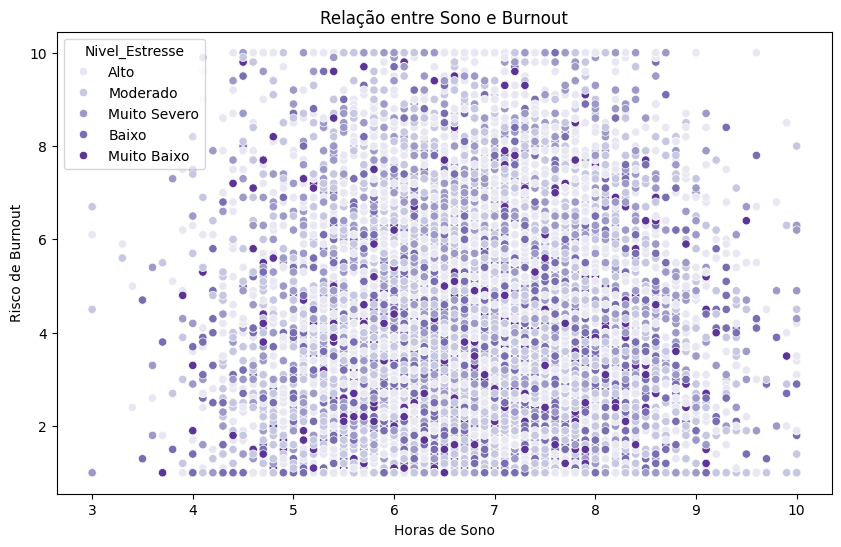

In [44]:
# Criando grafico de dispersao
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Horas_Sono_Noite',
    y='Risco_Burnout',
    hue='Nivel_Estresse',
    palette='Purples'
)

plt.title('Relação entre Sono e Burnout')
plt.xlabel('Horas de Sono')
plt.ylabel('Risco de Burnout')

plt.show()

# 22. Análises Gráficas 3
```
Modelo de Trabalho e Burnout
```

/tmp/ipykernel_14916/3398083876.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




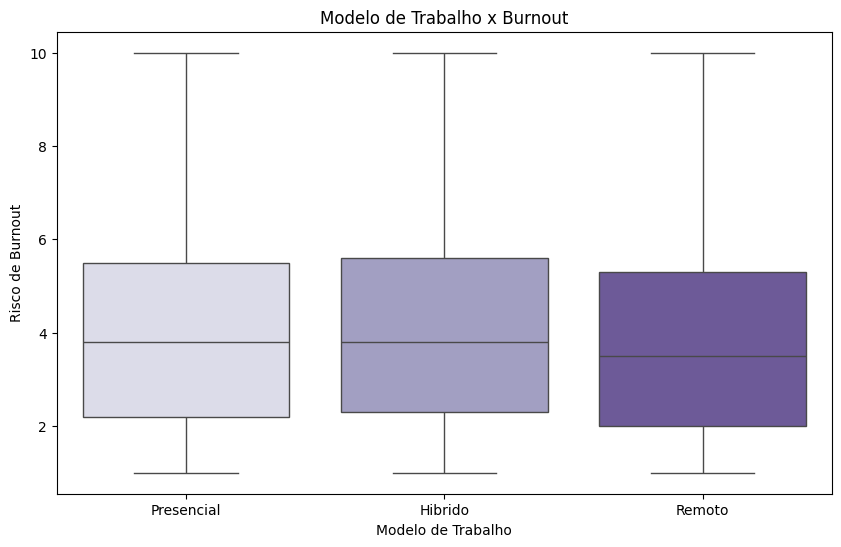

In [45]:
# Visualização em gráfico estilo Boxplot
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Modelo_Trabalho',
    y='Risco_Burnout',
    palette='Purples'
)

# Personalizacao
plt.title('Modelo de Trabalho x Burnout')
plt.xlabel('Modelo de Trabalho')
plt.ylabel('Risco de Burnout')

plt.show()

# 23. Análises Gráficas 4
```
Correlação entre Variáveis Numéricas
```

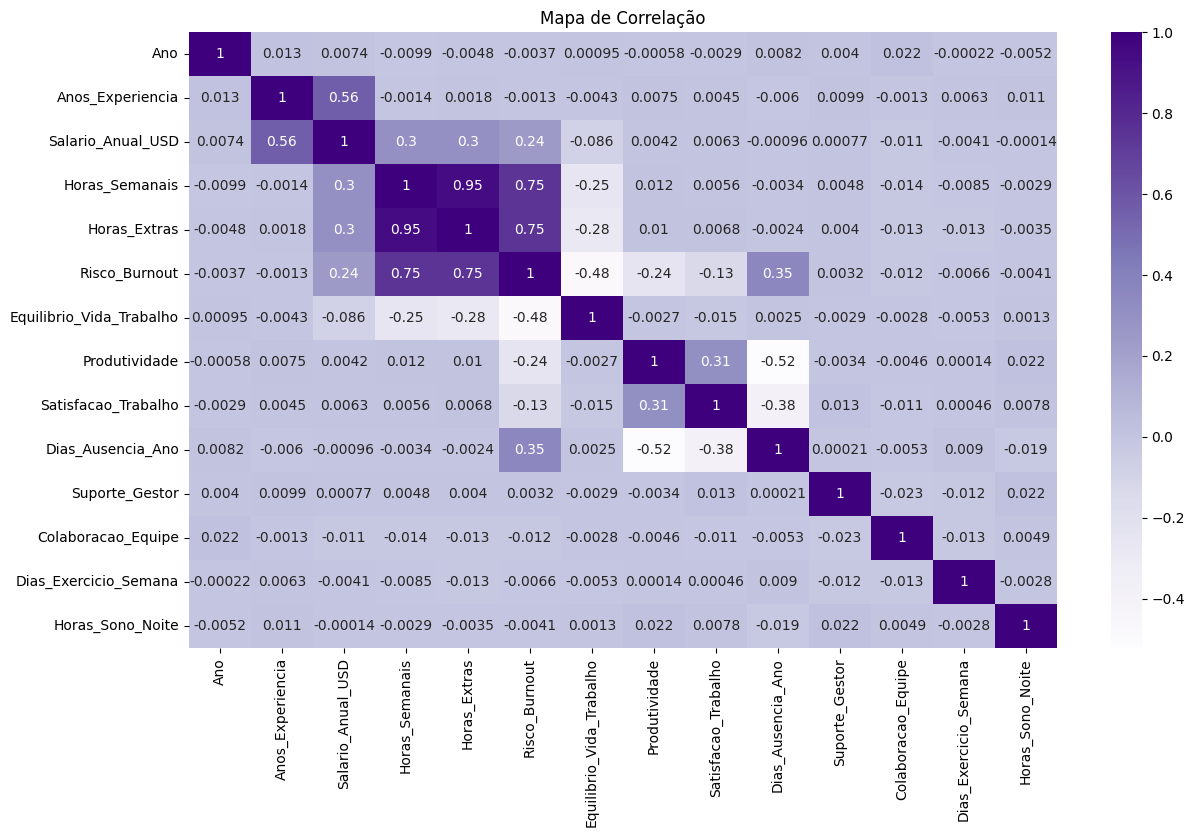

In [46]:
# Calculando correlacao
correlacao = df.select_dtypes(
    include='number'
).corr()

# Criando heatmap
plt.figure(figsize=(14,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='Purples'
)

# Personalização
plt.title('Mapa de Correlação')

plt.show()

# 24. Análises Gráficas 5
```
Distribuição do Nível de Estresse
```

/tmp/ipykernel_14916/2533028817.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




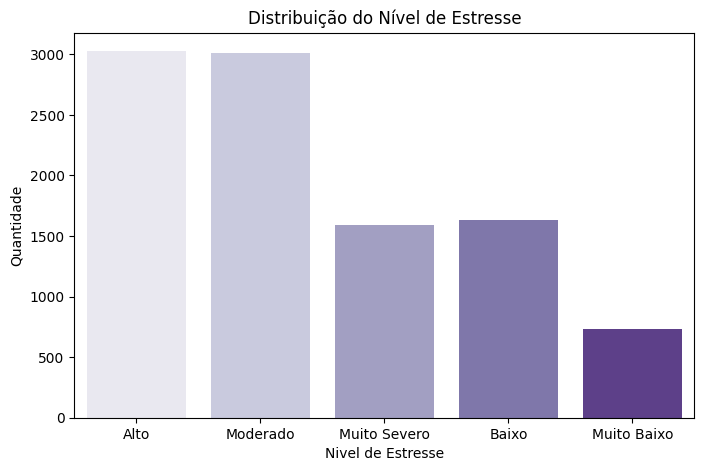

In [47]:
# Criando gráfico de barras
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Nivel_Estresse',
    palette='Purples'
)

# Personalização
plt.title('Distribuição do Nível de Estresse')
plt.xlabel('Nivel de Estresse')
plt.ylabel('Quantidade')

plt.show()

# 25. Análises Gráficas 6
```
Modelo de Trabalho e Nível de Estresse
```

In [48]:
# Criando gráfico hierarquico
fig = px.sunburst(
    df,
    path=['Modelo_Trabalho', 'Nivel_Estresse'],
    title='Modelo de Trabalho e Nível de Estresse',
    color='Risco_Burnout',
    color_continuous_scale='Purples'
)

# Personalizando layout
fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

# Exibindo grafico
fig.show()